In [147]:
from astropy.table import Table, vstack
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scienceplots
import fitsio
plt.style.use(['science', 'notebook', 'grid'])

In [7]:
table= Table(fitsio.read('north_merged_test.fits'))

In [16]:
np.count_nonzero(table['FLUX_Z']<=0) ,np.count_nonzero(table['FLUX_G']<=0) ,np.count_nonzero(table['FLUX_R']<=0)

(1465825, 1506969, 1386629)

In [21]:
len(table)

6250852

In [28]:
z_mask = (table['FLUX_Z'] > 0) & (table['FLUX_IVAR_Z'] > 0)
g_mask = (table['FLUX_G'] > 0) & (table['FLUX_IVAR_G'] > 0)
r_mask = (table['FLUX_R'] > 0) & (table['FLUX_IVAR_R'] > 0)
np.count_nonzero(z_mask) , np.count_nonzero(g_mask) ,np.count_nonzero(r_mask)

(4783744, 4741358, 4861413)

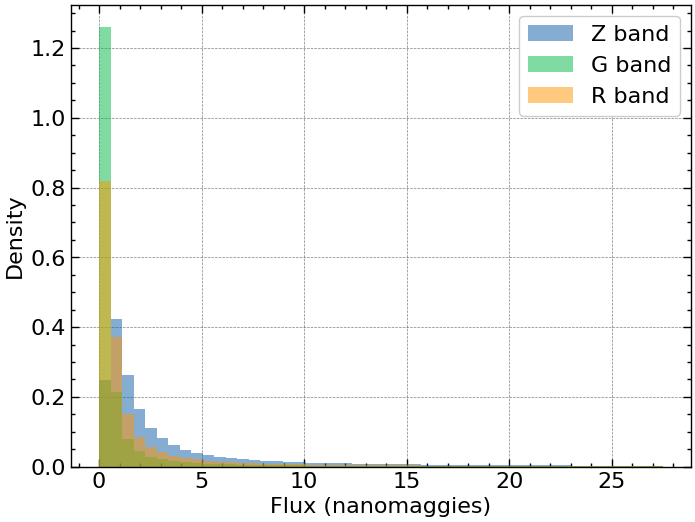

In [102]:
bins = np.linspace(0, np.percentile(table['FLUX_Z'][z_mask], 90), 50)
plt.hist(table['FLUX_Z'][z_mask], bins=bins, alpha=0.5, label='Z band', density=True)
plt.hist(table['FLUX_G'][g_mask], bins=bins, alpha=0.5, label='G band', density=True)
plt.hist(table['FLUX_R'][r_mask], bins=bins,  alpha=0.5, label='R band', density=True)
#plt.yscale('log')
plt.xlabel('Flux (nanomaggies)')
plt.ylabel('Density')
plt.legend()    

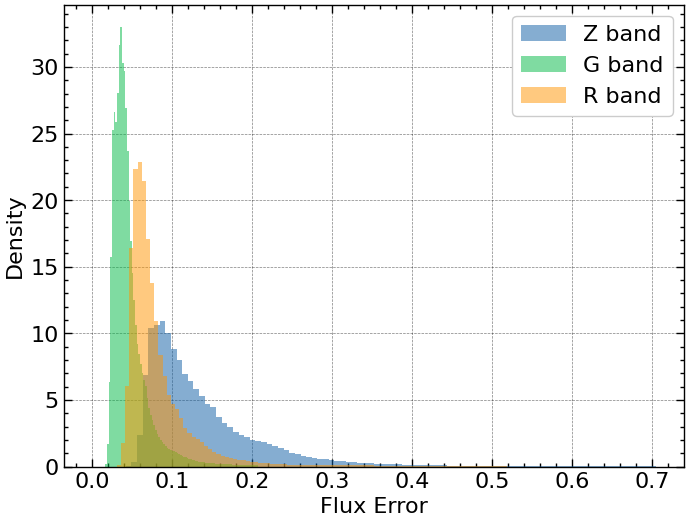

In [32]:
plt.hist(np.sqrt(1/table['FLUX_IVAR_Z'][z_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_Z'][z_mask]),98)), alpha=0.5, label='Z band', density=True)
plt.hist(np.sqrt(1/table['FLUX_IVAR_G'][g_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_G'][g_mask]),98)), alpha=0.5, label='G band', density=True)
plt.hist(np.sqrt(1/table['FLUX_IVAR_R'][r_mask]),bins = 100, range=(0,np.percentile(np.sqrt(1/table['FLUX_IVAR_R'][r_mask]),98)), alpha=0.5, label='R band', density=True)
plt.xlabel('Flux Error')
plt.ylabel('Density')
plt.legend()
plt.show()

In [42]:
max(table['FLUX_Z'][z_mask])

475530.75

In [41]:
np.percentile(table['FLUX_Z'][z_mask], 99.5)+10

1694.5978594970716

(-1.0, 1694.5978594970716)

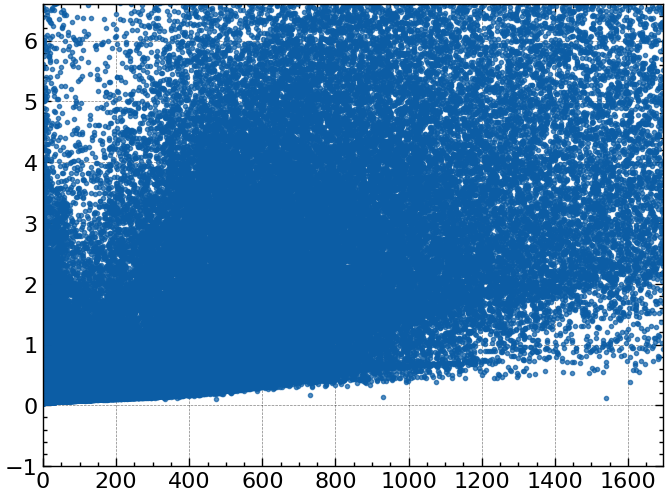

In [45]:
plt.plot(table['FLUX_Z'][z_mask], 1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]), '.', alpha=0.7)
plt.ylim(-1,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.5)+0.1)
plt.xlim(-1,np.percentile(table['FLUX_Z'][z_mask], 99.5)+10)

(-1.0, 2085.2963486327935)

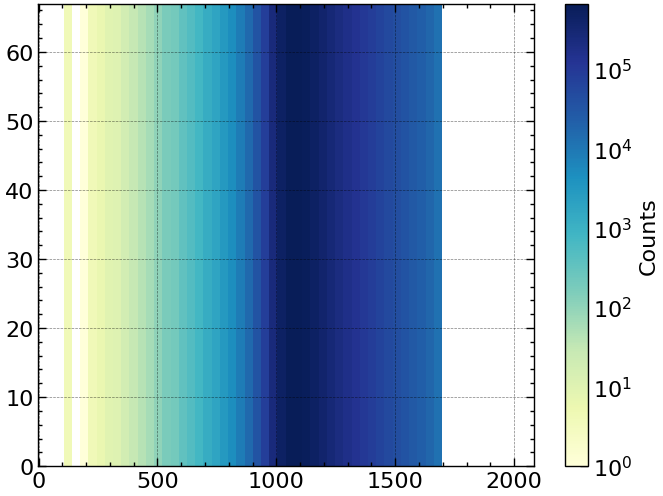

In [54]:
binx = np.logspace(np.log10(min(table['FLUX_Z'][z_mask])), np.log10(np.percentile(table['FLUX_Z'][z_mask], 99.5)+10), 50)
biny = np.linspace(min(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask])), max(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask])), 50)
hist,xedges,yedges=np.histogram2d(table['FLUX_Z'][z_mask], 1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]), bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',cmap='YlGnBu',norm=LogNorm())
plt.colorbar(label='Counts')
#plt.xscale('log')
plt.ylim(0,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.995)+0.1)
plt.xlim(-1,np.percentile(table['FLUX_Z'][z_mask], 99.6)+10)
#plt.ylim(-0.01,np.percentile(1/np.sqrt(table['FLUX_IVAR_Z'][z_mask]),99.5)+0.1)

In [83]:
def return_flux(flux_raw,ivar_raw):
    flux  = flux_raw
    sigma = 1 / np.sqrt(ivar_raw)

    good = np.isfinite(flux) & np.isfinite(sigma) & (flux > 0) & (sigma > 0)
    flux, sigma = flux[good], sigma[good]
    return flux, sigma

In [87]:
def compute_flux_error_stats(flux, sigma):
    # Define logarithmic bins for flux
    bins = np.logspace(
        np.log10(np.percentile(flux, 0.25)),
        np.log10(np.percentile(flux, 99.75)),
        100
    )
    bin_centers = 0.5 * (bins[1:] + bins[:-1])

    # Digitize flux values into bins
    bin_indices = np.digitize(flux, bins)

    # Vectorized computation of statistics per bin
    sigma_med = np.array([
        np.median(sigma[bin_indices == i]) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])

    sigma_p_lower = np.array([
        np.percentile(sigma[bin_indices == i], 0.3) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])

    sigma_p_upper = np.array([
        np.percentile(sigma[bin_indices == i], 99.7) if np.sum(bin_indices == i) > 20 else np.nan
        for i in range(1, len(bins))
    ])
    return bin_centers, sigma_med, sigma_p_lower, sigma_p_upper

In [88]:
flux,sigma = return_flux(table['FLUX_Z'], table['FLUX_IVAR_Z'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)

/tmp/ipykernel_853641/4267711751.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma = 1 / np.sqrt(ivar_raw)


/tmp/ipykernel_853641/4267711751.py:3: RuntimeWarning: divide by zero encountered in divide
  sigma = 1 / np.sqrt(ivar_raw)


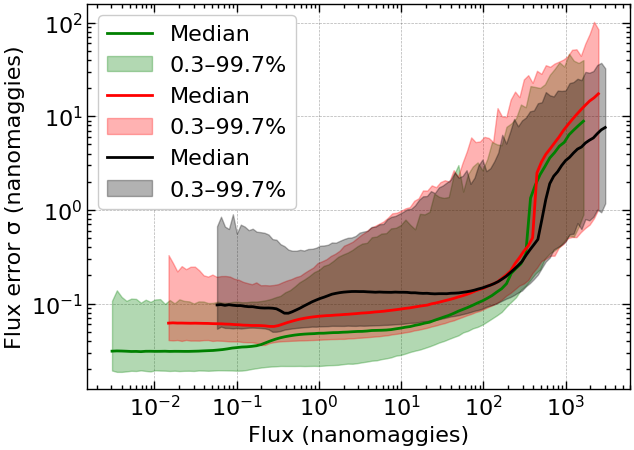

In [91]:
plt.figure(figsize=(7,5))
#plt.scatter(flux, sigma, s=2, alpha=0.05, color='gray')
flux,sigma = return_flux(table['FLUX_G'], table['FLUX_IVAR_G'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'g-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='green', alpha=0.3, label='0.3–99.7%'
)

flux,sigma = return_flux(table['FLUX_R'], table['FLUX_IVAR_R'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'r-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='red', alpha=0.3, label='0.3–99.7%'
)

flux,sigma = return_flux(table['FLUX_Z'], table['FLUX_IVAR_Z'])
bin_centers, sigma_med, sigma_p_lower, sigma_p_upper = compute_flux_error_stats(flux, sigma)
plt.plot(bin_centers, sigma_med, 'k-', lw=2, label='Median')
plt.fill_between(
    bin_centers, sigma_p_lower, sigma_p_upper,
    color='black', alpha=0.3, label='0.3–99.7%'
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Flux (nanomaggies)')
plt.ylabel('Flux error σ (nanomaggies)')
plt.legend()
#plt.plot(bin_centers, sigma_med * np.sqrt(bin_centers), '--')

plt.grid(alpha=0.3)


In [148]:
north_stats = Table.read('../flux_error_stats_north_test.fits')
south_stats = Table.read('../flux_error_stats_south.fits')

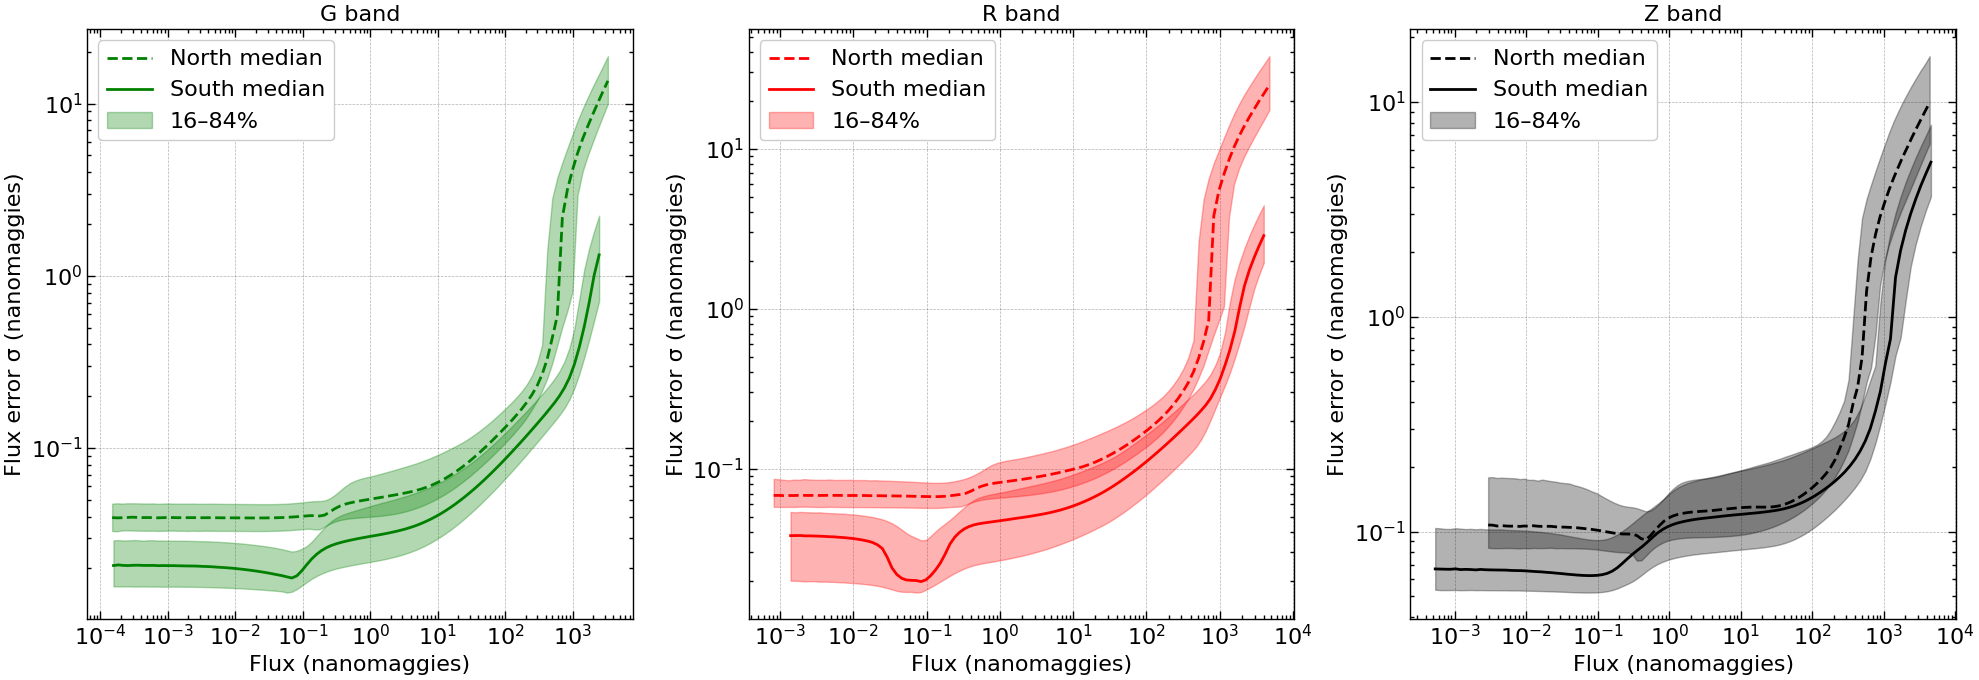

In [211]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, band in enumerate(['G', 'R', 'Z']):
    ax = axes[idx]
    band_stats_north = north_stats[north_stats['band'] == band]
    band_stats_south = south_stats[south_stats['band'] == band]
    
    ax.plot(
        band_stats_north['flux_bin_center'],
        band_stats_north['sigma_median'],
        lw=2,
        label='North median',
        ls='--',
        color=colors[band]
    )
    ax.fill_between(
        band_stats_north['flux_bin_center'],
        band_stats_north['sigma_p16'],
        band_stats_north['sigma_p84'],
        alpha=0.3,
        
        color=colors[band]
    )
    ax.plot(
        band_stats_south['flux_bin_center'],
        band_stats_south['sigma_median'],
        lw=2,
        label='South median',
        ls='-',
        color=colors[band]
    )
    ax.fill_between(
        band_stats_south['flux_bin_center'],
        band_stats_south['sigma_p16'],
        band_stats_south['sigma_p84'],
        alpha=0.3,
        label='16–84%',
        color=colors[band]
    )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Flux (nanomaggies)')
    ax.set_ylabel('Flux error σ (nanomaggies)')
    ax.set_title(f'{band} band')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

In [ ]:
cut = 5
n_iterations = 50000
n_samples_north = 10000
n_samples_south = 20000
# Pre-allocate array for results
outliers = np.zeros((n_iterations, 3))
sd_north = 0.5
sd_south = 0.1
# Vectorize the loop body
master_rng = np.random.default_rng(12345)
rngs = master_rng.spawn(n_iterations)
for i, rng in enumerate(rngs):
    
    # Generate all random values at once
    x_north_true = rng.uniform(0, 10, n_samples_north)
    x_south_true = rng.uniform(0, 10, n_samples_south)
    x_north_noise = rng.normal(0, sd_north, n_samples_north)
    x_south_noise = rng.normal(0, sd_south, n_samples_south)
    downgrade_noise = rng.normal(0, np.sqrt(sd_north**2 - sd_south**2), n_samples_south)
    
    # Compute measurements
    x_north_measured = x_north_true + x_north_noise
    x_south_measured = x_south_true + x_south_noise
    x_downgraded1 = x_south_measured + downgrade_noise
    
    # Apply cuts and count in one step
    outliers[i, 0] = np.sum((x_north_measured < cut) & (x_north_true > cut))/n_samples_north
    outliers[i, 1] = np.sum((x_south_measured < cut) & (x_south_true > cut))/n_samples_south
    outliers[i, 2] = np.sum((x_downgraded1 < cut) & (x_south_true > cut))/n_samples_south

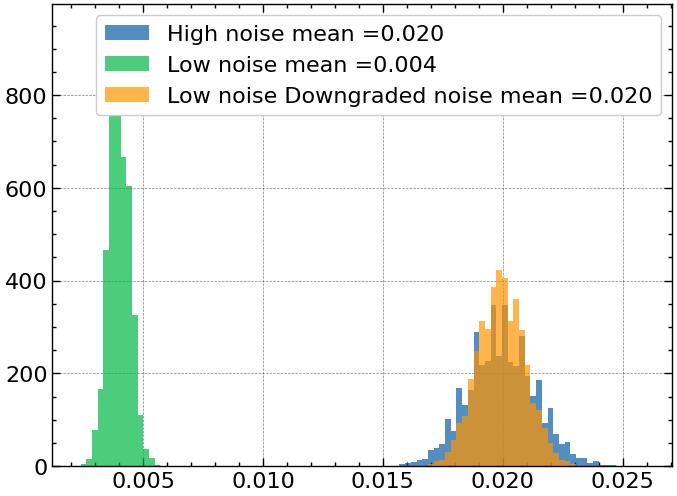

In [312]:
bins = np.linspace(np.min(outliers),np.max(outliers),100)
plt.hist(outliers[:,0],bins = bins,density=True,alpha=0.7, label=f'High noise mean ={np.mean(outliers[:,0]):.3f}')
plt.hist(outliers[:,1],bins = bins,density=True,alpha=0.7, label=f'Low noise mean ={np.mean(outliers[:,1]):.3f}')
plt.hist(outliers[:,2],bins = bins,density=True,alpha=0.7, label=f'Low noise Downgraded noise mean ={np.mean(outliers[:,2]):.3f}')
plt.legend()

In [291]:
hist_high

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [319]:
#KL divergence calculation
from scipy.stats import entropy
from scipy.special import rel_entr
bins = np.linspace(
    min(outliers[:,0].min(), outliers[:,2].min()),
    max(outliers[:,0].max(), outliers[:,2].max()),
    50
)
hist_high,_ = np.histogram(outliers[:,0], bins=bins, density=False)
np.random.choice
hist_low_downgraded,_ = np.histogram(outliers[:,2], bins=bins, density=False)
eps = 1e-10
P = (hist_high+eps)/np.sum(hist_high+eps)
Q = (hist_low_downgraded+eps)/np.sum(hist_low_downgraded+eps)
kl_divergence = entropy(P, Q)
print(f'KL Divergence between high noise and downgraded noise distributions: {kl_divergence}')

KL Divergence between high noise and downgraded noise distributions: 0.38538790923886046


In [320]:
KL_PQ = np.sum(rel_entr(P, Q))  # KL(P || Q)
KL_QP = np.sum(rel_entr(Q, P))  # KL(Q || P)

In [321]:
print(f'KL(P || Q): {KL_PQ}')
print(f'KL(Q || P): {KL_QP}')
print(f'Jensen-Shannon Divergence: {(KL_PQ + KL_QP) / 2}')

KL(P || Q): 0.38538790923886046
KL(Q || P): 0.11492218200967672
Jensen-Shannon Divergence: 0.2501550456242686


In [ ]:
#heteroskedastic noise addition
cut = 18



